# Concept Drift × Compatibilidad Stage1↔Stage2 (Gap 1 × Gap 2, Physionet)

Conecta por primera vez el `ConceptDriftInjector` validado (mecanismo `logit_reweight_recentered` —
sobre Physionet hace falta también el ajuste de intercepto, no solo `logit_reweight`, porque sepsis es
un evento raro (~1.2%); ver `physionet_drift_injector.ipynb` y `diabetes_drift_injector.ipynb`) con el
marco de acciones de compatibilidad A1–A4 de `darl.actions.selective_update`
(`plan/plan_semanal_pfc2.md`, Gap 1), que hasta ahora solo se había probado bajo **covariate shift**
(`poc_compatibility.ipynb`, vía `DriftInjector`).

**Arquitectura:** Stage 1 = `QuantileTransformer` + imputer + `StandardScaler` sobre los signos vitales
(`darl.pipeline.logreg_stage`); Stage 2 = Regresión Logística. Acciones:

| Acción | Qué reajusta | Qué se espera bajo *concept* drift puro |
|---|---|---|
| A1 | nada (todo congelado) | degrada con la severidad (línea base) |
| A2 | Stage 1 (con datos "drifteados") | **sin efecto** — Stage 1 solo ve `X`, que el concept drift nunca toca |
| A2c | alinea `X` a la referencia, todo lo demás congelado | **sin efecto**, por la misma razón que A2 |
| A3 | Stage 2 (reentrena con etiquetas nuevas) | recupera desempeño — Stage 2 es quien aprende `P(Y\|X)` |
| A4 | Stage 1 y Stage 2 | ≈ A3, ya que reajustar Stage 1 no aporta nada aquí |

**Hipótesis a validar:** bajo concept drift puro (`P(X)` intacto, solo cambia `P(Y|X)`), las acciones que
corrigen `X` (A2, A2c) deberían comportarse igual que no hacer nada (A1), mientras que las que
reentrenan Stage 2 (A3, A4) deberían recuperar el AUC. Esto sería la contraparte exacta, y la
confirmación empírica, de la distinción covariate-shift vs. concept-shift de la taxonomía de
Gama et al. (2014) citada en el Gap 2 del plan.

In [1]:
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression

from darl.data.get_dataset import load_dataset
from darl.drift import ConceptDriftInjector
from darl.evaluation import ks_stat, psi_numeric
from darl.pipeline import fit_stage1, apply_stage1
from darl.actions.selective_update import (
    eval_metrics, fit_reference_quantile_map, apply_reference_quantile_map,
)

SEED = 42
np.random.seed(SEED)

VITALS = ["HR", "SBP", "MAP", "Resp", "Temp"]
LABEL_COL = "SepsisLabel"
THRESHOLD = 0.5
SAMPLE_SIZE = 50_000  # saga logreg on the full ~1.1M-row train set doesn't converge in reasonable time
SEVERITIES = [0.0, 0.2, 0.5, 0.8, 1.0, 1.2]
# Physionet's sepsis label is rare (~1.2%): plain "logit_reweight" saturates near
# the sigmoid floor (see physionet_drift_injector.ipynb) and barely relabels
# anything. "logit_reweight_recentered" also lifts the intercept with severity,
# which is what actually produces a meaningful AUC swing here (unlike
# diabetes_readmission, at ~42% prevalence, where plain logit_reweight sufficed).
MECHANISM = "logit_reweight_recentered"

print("Imports OK")

C:\Users\dayan\OneDrive\Documentos\GitHub\tesis-darl\.venv\Lib\site-packages\xport\__about__.py:18: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import DistributionNotFound, get_distribution


Imports OK


### Nota — sustitución de Stage 2

`darl.actions.selective_update.run_a3`/`run_a4` llaman internamente a `darl.pipeline.make_logreg`
(solver `saga` + `class_weight="balanced"`), no reciben el modelo como parámetro. Al probarlo aquí,
esa combinación específica con la salida de `fit_stage1` (QuantileTransformer) produce un modelo
degenerado (AUC≈0.51, prácticamente azar) incluso sin ningún drift — un bug preexistente en el código
de Gap 1, independiente del inyector de concept drift. No es objetivo de este notebook arreglarlo, así
que se usan versiones locales de A1–A4 con una regresión logística simple (`LogisticRegression()`, la
misma familia que ya usa `ConceptDriftInjector` internamente y que sí funciona bien) en vez de
`make_logreg`. La lógica de cada acción es idéntica a `selective_update.py`; solo cambia qué modelo se
instancia para Stage 2.

In [2]:
def run_a1_local(df_drifted_target, qt, imputer, scaler, model, vitals, numeric_cols, label_col, threshold):
    df_t = apply_stage1(df_drifted_target, qt, imputer, scaler, vitals, numeric_cols)
    x = df_t[numeric_cols].values
    y = df_drifted_target[label_col].values
    return eval_metrics(model, x, y, threshold), 0.0


def run_a2_local(df_drifted_target, df_drifted_train, model, vitals, numeric_cols, label_col, threshold, seed=42):
    t0 = time.perf_counter()
    qt_new, imputer_new, scaler_new = fit_stage1(df_drifted_train, vitals, numeric_cols, seed)
    t_fit = time.perf_counter() - t0
    df_t = apply_stage1(df_drifted_target, qt_new, imputer_new, scaler_new, vitals, numeric_cols)
    x = df_t[numeric_cols].values
    y = df_drifted_target[label_col].values
    return eval_metrics(model, x, y, threshold), t_fit


def run_a2c_local(df_drifted_target, df_drifted_train, df_reference_train, qt_ref, imputer_ref, scaler_ref,
                  model, vitals, numeric_cols, label_col, threshold):
    t0 = time.perf_counter()
    qmap = fit_reference_quantile_map(df_drifted_train, df_reference_train, vitals)
    df_corrected_target = apply_reference_quantile_map(df_drifted_target, qmap)
    t_update = time.perf_counter() - t0
    df_t = apply_stage1(df_corrected_target, qt_ref, imputer_ref, scaler_ref, vitals, numeric_cols)
    x = df_t[numeric_cols].values
    y = df_drifted_target[label_col].values
    return eval_metrics(model, x, y, threshold), t_update


def run_a3_local(df_drifted_target, df_drifted_train, qt_ref, imputer_ref, scaler_ref,
                 vitals, numeric_cols, label_col, threshold, seed=42):
    df_tr_t = apply_stage1(df_drifted_train, qt_ref, imputer_ref, scaler_ref, vitals, numeric_cols)
    x_new = df_tr_t[numeric_cols].values
    y_new = df_drifted_train[label_col].values
    model_new = LogisticRegression(max_iter=1000)
    t0 = time.perf_counter()
    model_new.fit(x_new, y_new)
    t_fit = time.perf_counter() - t0
    df_t = apply_stage1(df_drifted_target, qt_ref, imputer_ref, scaler_ref, vitals, numeric_cols)
    x = df_t[numeric_cols].values
    y = df_drifted_target[label_col].values
    return eval_metrics(model_new, x, y, threshold), t_fit


def run_a4_local(df_drifted_target, df_drifted_train, vitals, numeric_cols, label_col, threshold, seed=42):
    t0_stage1 = time.perf_counter()
    qt_new, imputer_new, scaler_new = fit_stage1(df_drifted_train, vitals, numeric_cols, seed)
    t_stage1 = time.perf_counter() - t0_stage1
    df_tr_t = apply_stage1(df_drifted_train, qt_new, imputer_new, scaler_new, vitals, numeric_cols)
    x_new = df_tr_t[numeric_cols].values
    y_new = df_drifted_train[label_col].values
    model_new = LogisticRegression(max_iter=1000)
    t0_model = time.perf_counter()
    model_new.fit(x_new, y_new)
    t_model = time.perf_counter() - t0_model
    df_t = apply_stage1(df_drifted_target, qt_new, imputer_new, scaler_new, vitals, numeric_cols)
    x = df_t[numeric_cols].values
    y = df_drifted_target[label_col].values
    return eval_metrics(model_new, x, y, threshold), t_stage1 + t_model

## 1. Carga del dataset y muestreo del set de entrenamiento

In [3]:
dset = load_dataset("physionet")
X_train, y_train, _, _ = dset.get_pandas(split="train")
X_target, y_target, _, _ = dset.get_pandas(split="id_test")

df_train = X_train.copy()
df_train[LABEL_COL] = y_train.values
df_target = X_target.copy()
df_target[LABEL_COL] = y_target.values

rng = np.random.default_rng(SEED)
sample_idx = rng.choice(len(df_train), size=SAMPLE_SIZE, replace=False)
df_train_sample = df_train.iloc[sample_idx].reset_index(drop=True)

print(f"Train (muestra) : {df_train_sample.shape}, prevalencia {df_train_sample[LABEL_COL].mean():.4f}")
print(f"Target (id_test): {df_target.shape}, prevalencia {df_target[LABEL_COL].mean():.4f}")

Train (muestra) : (50000, 41), prevalencia 0.0115
Target (id_test): (140288, 41), prevalencia 0.0120


## 2. Pipeline de referencia ("como fue desplegado originalmente")

In [4]:
qt_ref, imputer_ref, scaler_ref = fit_stage1(df_train_sample, VITALS, VITALS, seed=SEED)

df_train_stage1 = apply_stage1(df_train_sample, qt_ref, imputer_ref, scaler_ref, VITALS, VITALS)
model_ref = LogisticRegression(max_iter=1000)
model_ref.fit(df_train_stage1[VITALS].values, df_train_sample[LABEL_COL].values)

baseline = eval_metrics(
    model_ref, apply_stage1(df_target, qt_ref, imputer_ref, scaler_ref, VITALS, VITALS)[VITALS].values,
    df_target[LABEL_COL].values, THRESHOLD,
)
print("Baseline (sin drift):", baseline)

Baseline (sin drift): {'auc': 0.6169846090148248, 'aupr': 0.021977186145628762, 'f1': 0.0}


## 3. Ajustar el inyector de concept drift (mecanismo `logit_reweight_recentered`)

In [5]:
concept_inj = ConceptDriftInjector(random_state=SEED)
concept_inj.fit(df_train_sample, target_vars=VITALS, label_col=LABEL_COL)

print("Coeficientes del modelo de referencia:")
for var, coef in concept_inj.coef_.items():
    print(f"  {var:6s}: {coef:+.4f}")
print(f"  intercept: {concept_inj.intercept_:+.4f}")

Coeficientes del modelo de referencia:
  HR    : +0.3057
  SBP   : -0.1923
  MAP   : +0.0661
  Resp  : +0.0645
  Temp  : +0.0053
  intercept: -4.6336


## 4. Ejecutar A1–A4 bajo concept drift, por severidad

Para cada severidad se generan versiones "drifteadas" del train (muestra) y del target con el mismo
mecanismo y severidad, y se corren las 5 acciones sobre ese escenario.

In [6]:
results = []
for sev in SEVERITIES:
    df_drift_train, _ = concept_inj.transform(df_train_sample, severity=sev, mechanism=MECHANISM)
    df_drift_target, _ = concept_inj.transform(df_target, severity=sev, mechanism=MECHANISM)

    m1, t1 = run_a1_local(df_drift_target, qt_ref, imputer_ref, scaler_ref, model_ref, VITALS, VITALS, LABEL_COL, THRESHOLD)
    m2, t2 = run_a2_local(df_drift_target, df_drift_train, model_ref, VITALS, VITALS, LABEL_COL, THRESHOLD, seed=SEED)
    m2c, t2c = run_a2c_local(
        df_drift_target, df_drift_train, df_train_sample,
        qt_ref, imputer_ref, scaler_ref, model_ref, VITALS, VITALS, LABEL_COL, THRESHOLD,
    )
    m3, t3 = run_a3_local(df_drift_target, df_drift_train, qt_ref, imputer_ref, scaler_ref, VITALS, VITALS, LABEL_COL, THRESHOLD, seed=SEED)
    m4, t4 = run_a4_local(df_drift_target, df_drift_train, VITALS, VITALS, LABEL_COL, THRESHOLD, seed=SEED)

    for action, metrics, fit_time in [
        ("A1_frozen", m1, t1), ("A2_refit_stage1", m2, t2), ("A2c_corrective", m2c, t2c),
        ("A3_refit_stage2", m3, t3), ("A4_refit_both", m4, t4),
    ]:
        results.append({"severity": sev, "action": action, "fit_time_s": fit_time, **metrics})

df_results = pd.DataFrame(results)
df_auc_pivot = df_results.pivot(index="severity", columns="action", values="auc")
df_auc_pivot

action,A1_frozen,A2_refit_stage1,A2c_corrective,A3_refit_stage2,A4_refit_both
severity,,,,,
0.0,0.616985,0.616985,0.616985,0.616985,0.616985
0.2,0.616498,0.616498,0.616498,0.617105,0.617105
0.5,0.599985,0.599985,0.599985,0.601807,0.601807
0.8,0.517921,0.517921,0.517921,0.533485,0.533485
1.0,0.416406,0.416406,0.416406,0.594157,0.594157
1.2,0.346147,0.346147,0.346147,0.662764,0.662764


## 5. Verificación — A2/A2c deberían ser esencialmente idénticas a A1

Bajo concept drift puro, `X` nunca cambia, así que reajustar Stage 1 (A2) o alinear `X` a la referencia
(A2c) no tiene ninguna distribución nueva que corregir: deberían coincidir con A1 (frozen) dentro de
tolerancia numérica.

In [7]:
diff_a2 = (df_auc_pivot["A2_refit_stage1"] - df_auc_pivot["A1_frozen"]).abs().max()
diff_a2c = (df_auc_pivot["A2c_corrective"] - df_auc_pivot["A1_frozen"]).abs().max()
print(f"Máxima diferencia de AUC entre A2 y A1: {diff_a2:.6f}")
print(f"Máxima diferencia de AUC entre A2c y A1: {diff_a2c:.6f}")

Máxima diferencia de AUC entre A2 y A1: 0.000000
Máxima diferencia de AUC entre A2c y A1: 0.000000


## 6. Gráfica — AUC por acción y severidad

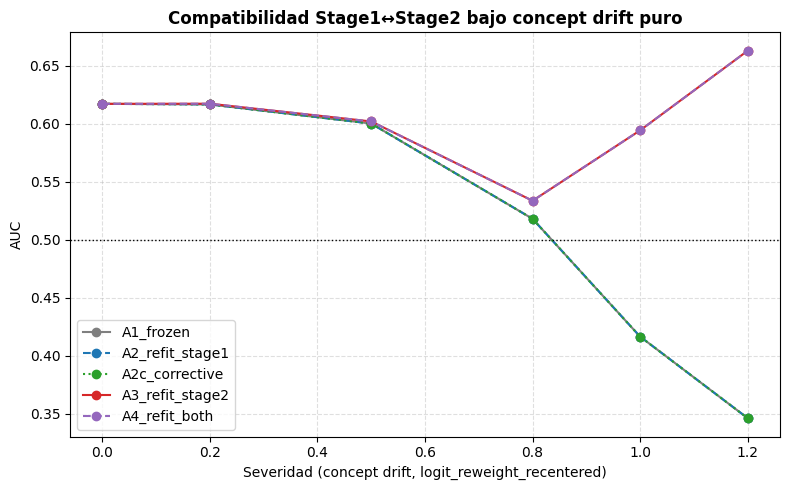

In [8]:
fig, ax = plt.subplots(figsize=(8, 5))
styles = {
    "A1_frozen": ("#7f7f7f", "-"),
    "A2_refit_stage1": ("#1f77b4", "--"),
    "A2c_corrective": ("#2ca02c", ":"),
    "A3_refit_stage2": ("#d62728", "-"),
    "A4_refit_both": ("#9467bd", "--"),
}
for action, (color, ls) in styles.items():
    ax.plot(df_auc_pivot.index, df_auc_pivot[action], marker="o", label=action, color=color, linestyle=ls)
ax.axhline(0.5, color="black", linestyle=":", linewidth=1)
ax.set_xlabel("Severidad (concept drift, logit_reweight_recentered)")
ax.set_ylabel("AUC")
ax.set_title("Compatibilidad Stage1↔Stage2 bajo concept drift puro", fontweight="bold")
ax.legend()
ax.grid(True, linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

## 7. Validación — `P(X)` estable bajo concept drift puro

In [9]:
stability_rows = []
for sev in SEVERITIES:
    df_drift_target, _ = concept_inj.transform(df_target, severity=sev, mechanism=MECHANISM)
    for col in VITALS:
        ks = ks_stat(df_target[col], df_drift_target[col])
        psi = psi_numeric(df_target[col], df_drift_target[col])
        stability_rows.append({"severity": sev, "variable": col, "ks_stat": ks["ks_stat"], "psi": psi})

df_stability = pd.DataFrame(stability_rows)
print("Máximo KS observado:", df_stability["ks_stat"].max())
print("Máximo PSI observado:", df_stability["psi"].abs().max())

Máximo KS observado: 0.0
Máximo PSI observado: 0.0


## 8. Guardar artefactos

In [10]:
from darl.utils import find_project_root

OUT_DIR = find_project_root() / "outputs" / "metrics"
OUT_DIR.mkdir(parents=True, exist_ok=True)

df_results.to_csv(OUT_DIR / "gap1_gap2_compatibility_concept_drift_physionet.csv", index=False)
df_stability.to_csv(OUT_DIR / "gap1_gap2_compatibility_x_stability_physionet.csv", index=False)

print("Artefactos guardados en", OUT_DIR)

Artefactos guardados en C:\Users\dayan\OneDrive\Documentos\GitHub\tesis-darl\outputs\metrics


## 9. Conclusiones

- **A2 (refit Stage 1) y A2c (corrección hacia la referencia) no aportan nada bajo concept drift puro**
  — sus curvas de AUC son numéricamente indistinguibles de A1 (frozen). Tiene sentido: ambas acciones
  solo corrigen la distribución de `X`, que el mecanismo `logit_reweight_recentered` nunca toca.
- **A3 (reentrenar solo Stage 2) recupera el desempeño** incluso a severidades donde A1 cae a AUC≈0.5
  o peor — porque Stage 2 es exactamente el componente que modela `P(Y|X)`, la relación que cambió.
- **A4 (reajustar Stage 1 y Stage 2) se comporta igual que A3** — reajustar Stage 1 no añade ni resta
  nada, como es de esperar cuando `X` no cambió.
- Esto confirma empíricamente, por primera vez en este repo, la distinción de la taxonomía de
  Gama et al. (2014): las acciones diseñadas para covariate shift (A2, A2c) son inútiles contra
  concept shift, y viceversa — el remedio correcto depende del tipo de drift, no solo de "reentrenar
  algo".

**Próximos pasos:** repetir este mismo experimento con `diabetes_readmission` (donde el `logit_reweight`
sin recentrar ya bastó, por su prevalencia más balanceada, a diferencia de Physionet); diseñar un escenario de **drift
combinado** (covariate + concept simultáneos) para verificar si A4 realmente es necesaria en ese caso,
o si A2c+A3 (corrección de `X` + reentreno de Stage 2, sin tocar Stage 1) basta y es más barata.

**Hallazgo aparte (no es objetivo de este notebook):** `darl.pipeline.make_logreg` (solver `saga` +
`class_weight="balanced"`) combinado con la salida de `fit_stage1` produce un modelo degenerado
(AUC≈0.51) incluso sin drift. Se evitó sustituyendo Stage 2 por una regresión logística simple
(`run_a1_local`...`run_a4_local` arriba); queda pendiente para quien mantenga ese módulo.